In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav_history = pd.read_csv("../data/raw/02_nav_history.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
print(fund_master.columns)
print(nav_history.columns)
print(aum.columns)
print(sip.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')
Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [4]:
print(category.columns)
print(folio.columns)
print(performance.columns)
print(transactions.columns)
print(holdings.columns)
print(benchmark.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='str')
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')
Index(['date', 'index_name', 'close_value'], 

In [5]:
category.head()


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [6]:
folio.head()


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [7]:
performance.head()


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [8]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [9]:
benchmark.head()


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [11]:
nav_history['date'] = pd.to_datetime(
    nav_history['date'],
    dayfirst=True
)

nav_history['nav'] = pd.to_numeric(
    nav_history['nav']
)

ValueError: unconverted data remains when parsing with format "%Y-%d-%m": "3". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [12]:
print(nav_history['date'].head(10))

0    2022-01-03
1    2022-01-04
2    2022-01-05
3    2022-01-06
4    2022-01-07
5    2022-01-10
6    2022-01-11
7    2022-01-12
8    2022-01-13
9    2022-01-14
Name: date, dtype: str


In [13]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

In [14]:
nav_history['nav'] = pd.to_numeric(nav_history['nav'])

In [15]:
fig = px.line(
    nav_history,
    x='date',
    y='nav',
    title='Daily NAV Trend'
)

fig.show()


In [16]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [17]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [18]:
aum['date'] = pd.to_datetime(aum['date'])
aum['year'] = aum['date'].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [19]:
aum_yearly = (
    aum.groupby(['year', 'fund_house'])['aum_lakh_crore']
    .mean()
    .reset_index()
)

aum_yearly.head()

,year,fund_house,aum_lakh_crore
0,2022,Aditya Birla Sun Life MF,2.815
1,2022,Axis Mutual Fund,2.450
2,2022,DSP Mutual Fund,1.110
3,2022,HDFC Mutual Fund,4.400
4,2022,ICICI Prudential MF,4.765


In [20]:
top_funds = (
    aum.groupby('fund_house')['aum_lakh_crore']
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index
)

aum_top = aum_yearly[
    aum_yearly['fund_house'].isin(top_funds)
]

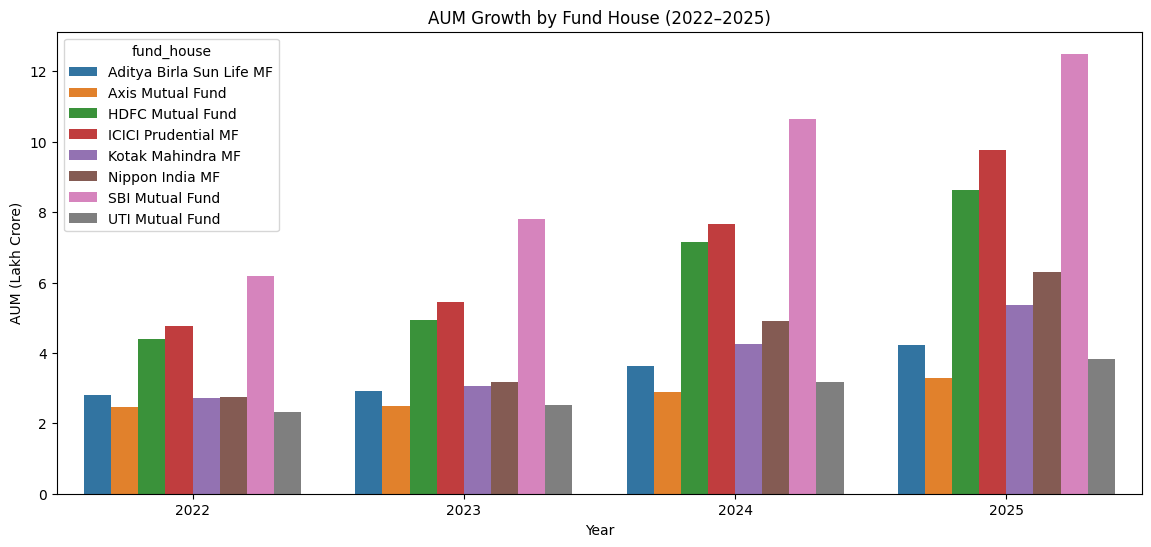

In [21]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_top,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title('AUM Growth by Fund House (2022–2025)')
plt.ylabel('AUM (Lakh Crore)')
plt.xlabel('Year')

plt.xticks(rotation=0)

plt.show()

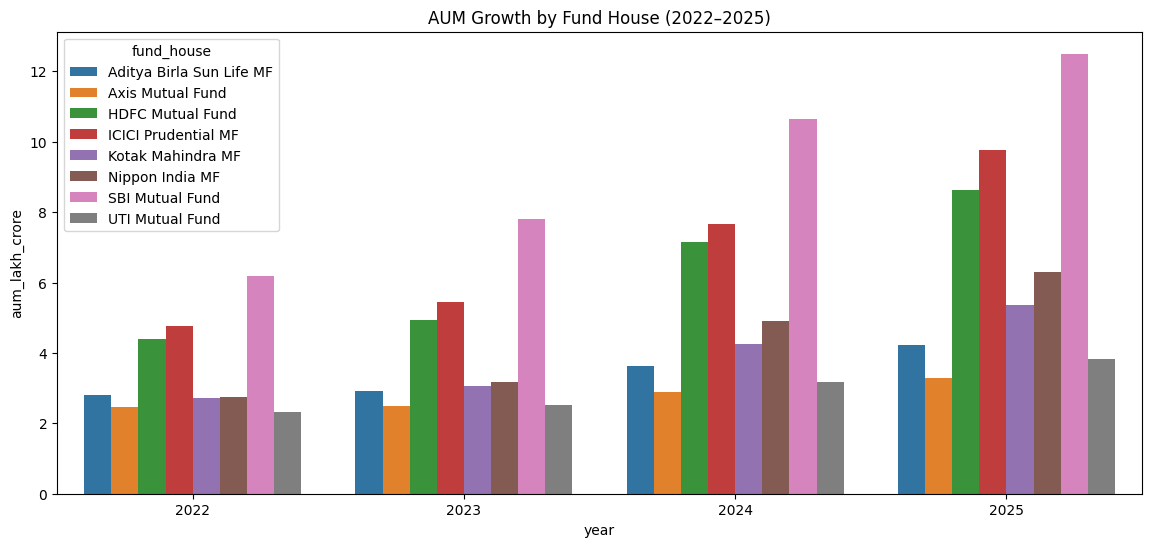

In [22]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_top,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title('AUM Growth by Fund House (2022–2025)')

plt.savefig(
    "../charts/aum_growth.png",
    bbox_inches="tight"
)

plt.show()

In [23]:
import os

os.listdir("../charts")

['aum_growth.png']

In [24]:
sip['month'] = pd.to_datetime(sip['month'])

sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[us]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 2.4 KB


In [25]:
sip[['month','sip_inflow_crore']].sort_values(
    by='sip_inflow_crore',
    ascending=False
).head()

,month,sip_inflow_crore
47,2025-12-01,31002
46,2025-11-01,30200
45,2025-10-01,29529
44,2025-09-01,29361
42,2025-07-01,28464


In [26]:
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows (2022-2025)',
    markers=True
)

fig.show()

In [27]:
peak = sip.loc[
    sip['sip_inflow_crore'].idxmax()
]

peak

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [28]:
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows (2022-2025)',
    markers=True
)

fig.add_annotation(
    x=peak['month'],
    y=peak['sip_inflow_crore'],
    text="₹31,002 Cr Peak",
    showarrow=True
)

fig.show()

In [29]:
fig.write_html("../charts/sip_trend.html")

In [30]:
import os

os.listdir("../charts")

['aum_growth.png', 'sip_trend.html']

In [31]:
category['month'] = pd.to_datetime(category['month'])

category.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [32]:
heatmap_data = category.pivot_table(
    values='net_inflow_crore',
    index='category',
    columns='month'
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


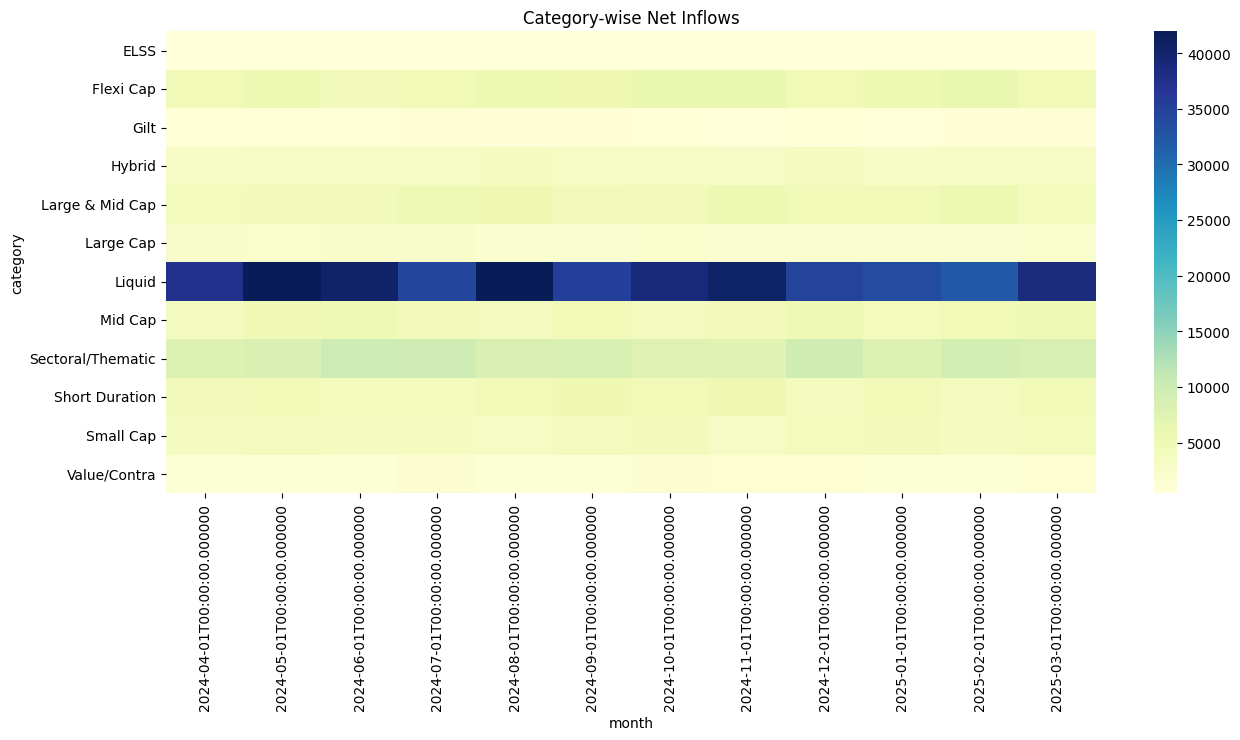

In [33]:
plt.figure(figsize=(15,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title('Category-wise Net Inflows')

plt.show()

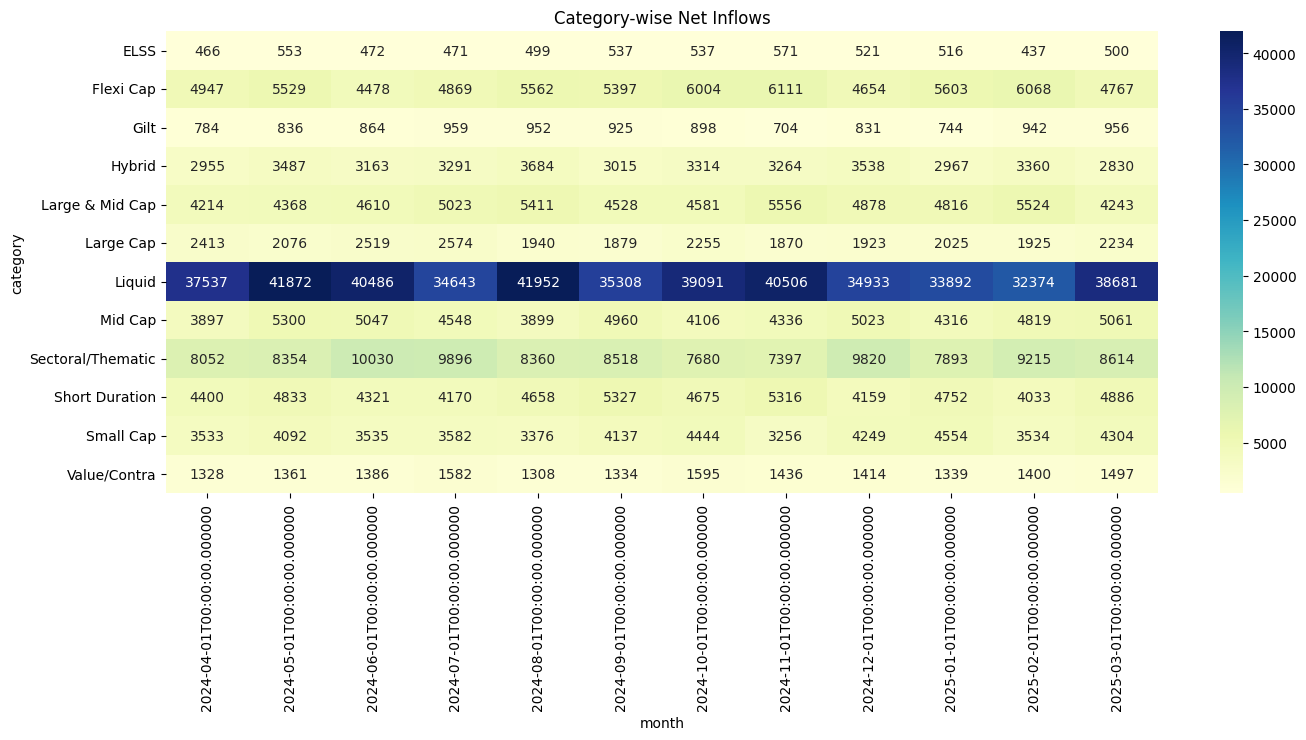

In [34]:
plt.figure(figsize=(16,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=True,
    fmt='.0f'
)

plt.title('Category-wise Net Inflows')

plt.show()

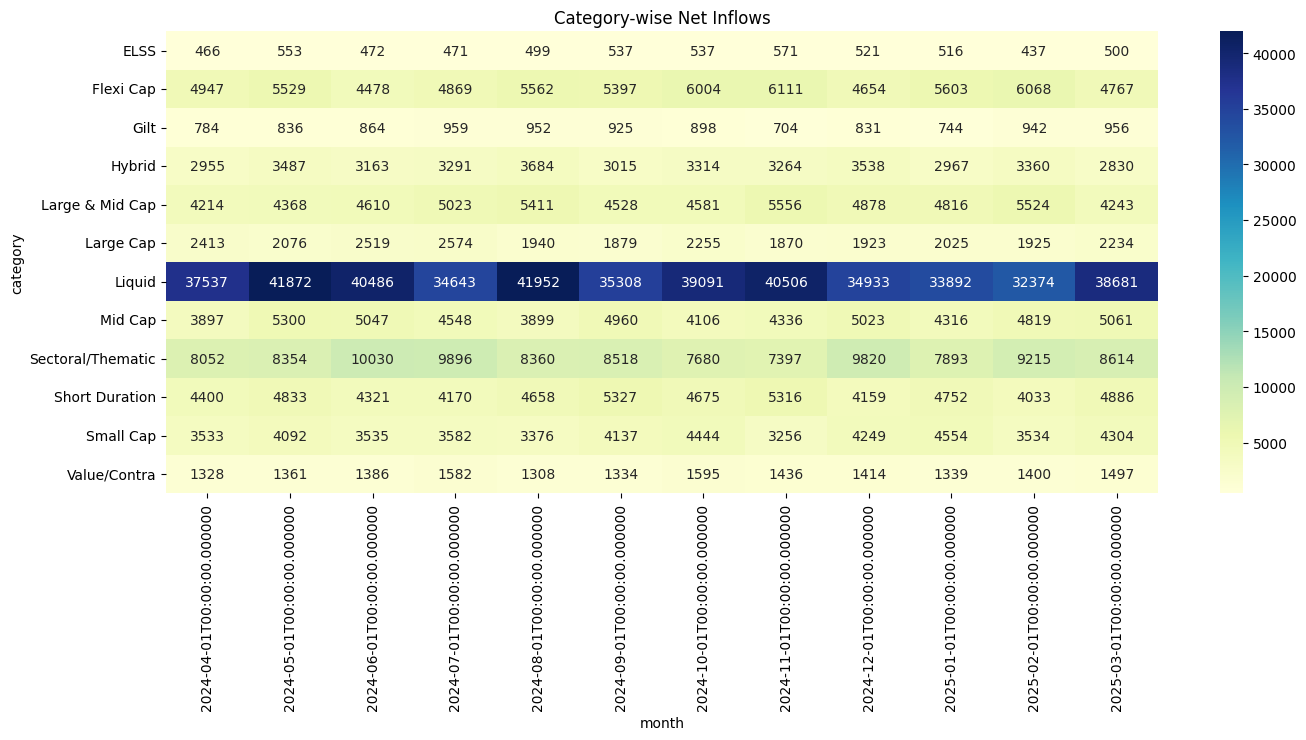

In [35]:
plt.figure(figsize=(16,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=True,
    fmt='.0f'
)

plt.title('Category-wise Net Inflows')

plt.savefig(
    "../charts/category_heatmap.png",
    bbox_inches='tight'
)

plt.show()

In [36]:
import os

print(os.listdir("../charts"))

['aum_growth.png', 'category_heatmap.png', 'sip_trend.html']


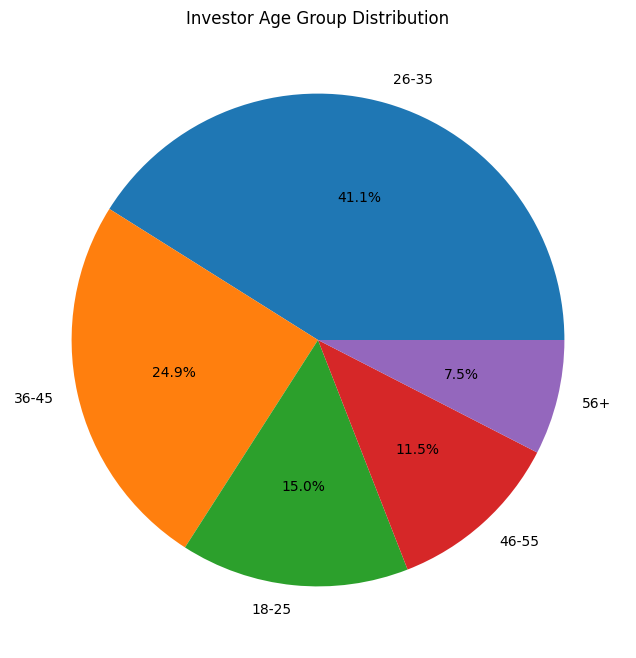

In [37]:
plt.figure(figsize=(8,8))

transactions['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Investor Age Group Distribution')

plt.ylabel('')

plt.show()

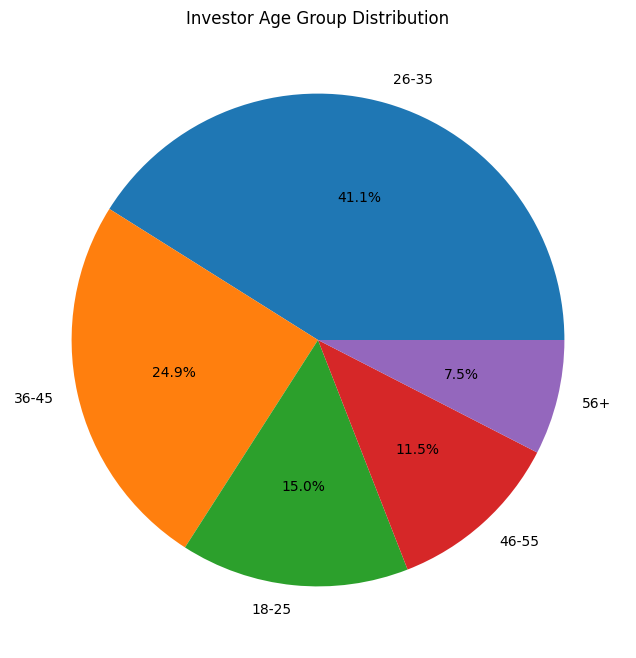

In [38]:
plt.figure(figsize=(8,8))

transactions['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Investor Age Group Distribution')

plt.ylabel('')

plt.savefig(
    "../charts/age_distribution.png",
    bbox_inches='tight'
)

plt.show()

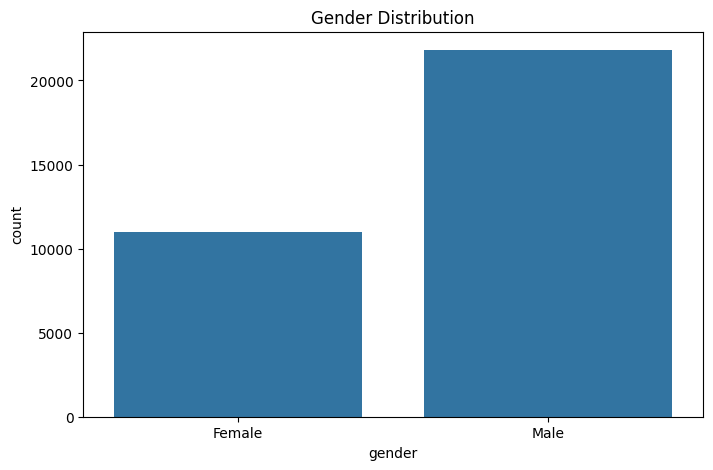

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x='gender'
)

plt.title('Gender Distribution')

plt.show()

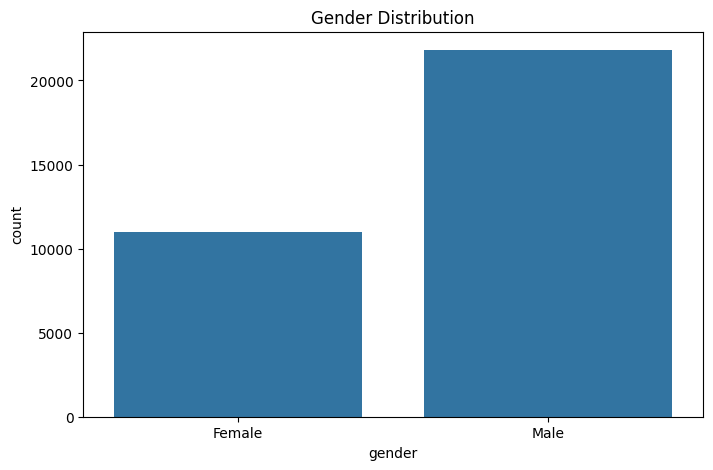

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x='gender'
)

plt.title('Gender Distribution')

plt.savefig(
    "../charts/gender_distribution.png",
    bbox_inches='tight'
)

plt.show()

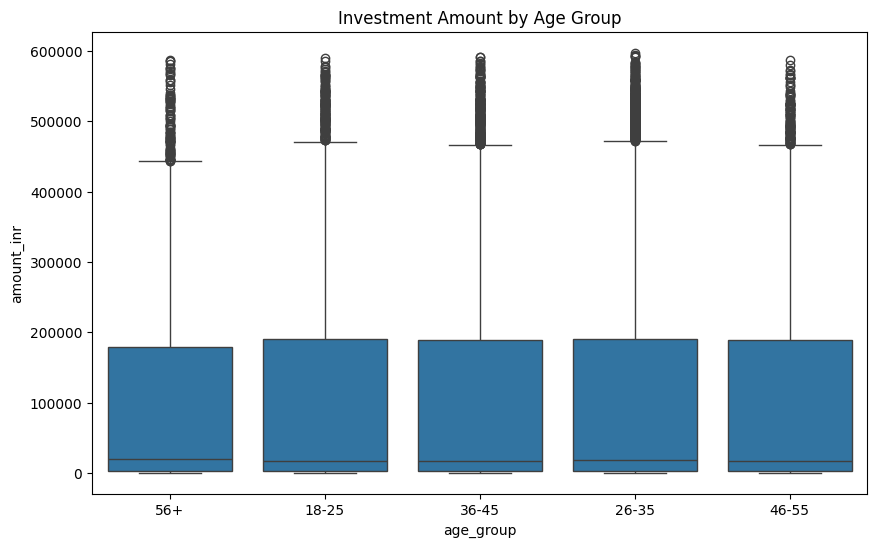

In [41]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x='age_group',
    y='amount_inr'
)

plt.title('Investment Amount by Age Group')

plt.savefig(
    "../charts/age_group_boxplot.png",
    bbox_inches='tight'
)

plt.show()

In [42]:
import os

print(os.listdir("../charts"))

['age_distribution.png', 'age_group_boxplot.png', 'aum_growth.png', 'category_heatmap.png', 'gender_distribution.png', 'sip_trend.html']


In [43]:
state_data = (
    transactions.groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=True)
)

state_data.head()

state
Maharashtra      269513480
Karnataka        273753570
Haryana          279634354
Uttar Pradesh    285368873
Delhi            289633404
Name: amount_inr, dtype: int64

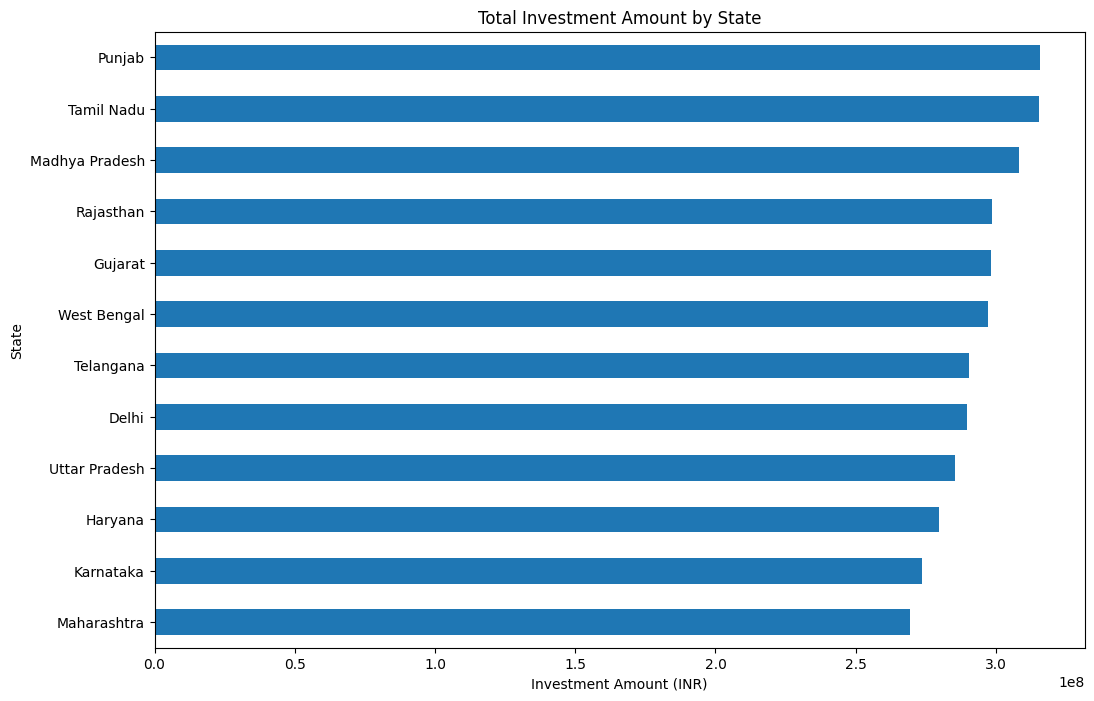

In [44]:
plt.figure(figsize=(12,8))

state_data.plot(
    kind='barh'
)

plt.title('Total Investment Amount by State')
plt.xlabel('Investment Amount (INR)')
plt.ylabel('State')

plt.show()

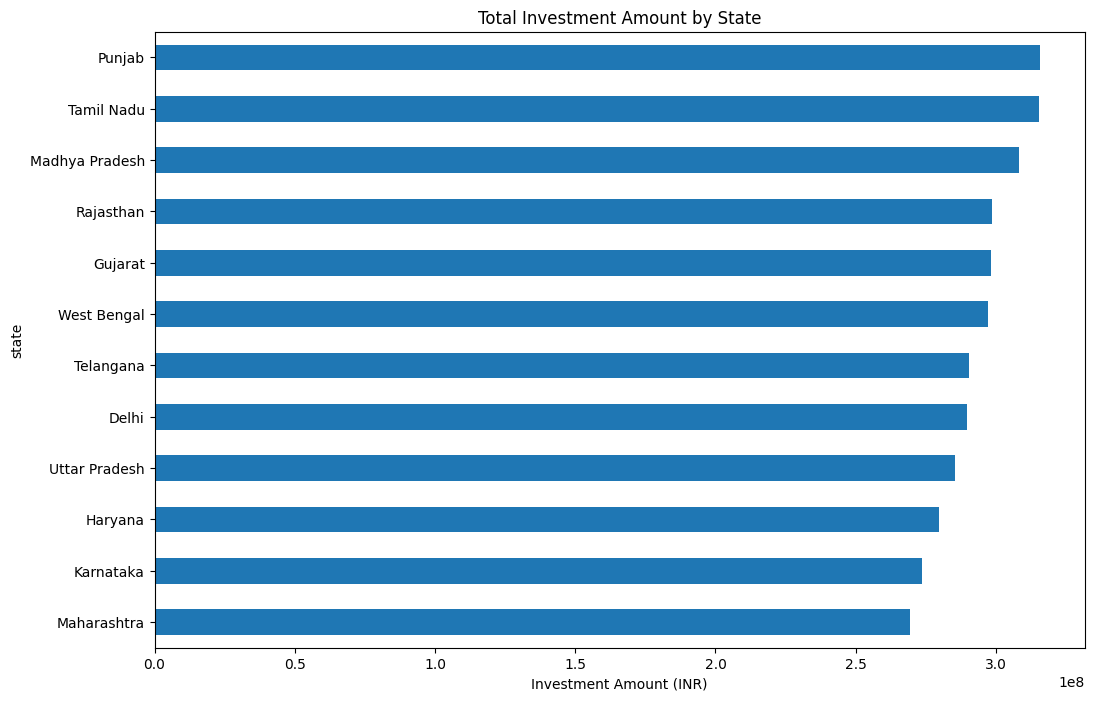

In [45]:
plt.figure(figsize=(12,8))

state_data.plot(
    kind='barh'
)

plt.title('Total Investment Amount by State')
plt.xlabel('Investment Amount (INR)')

plt.savefig(
    "../charts/state_investment.png",
    bbox_inches='tight'
)

plt.show()

In [46]:
transactions['city_tier'].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

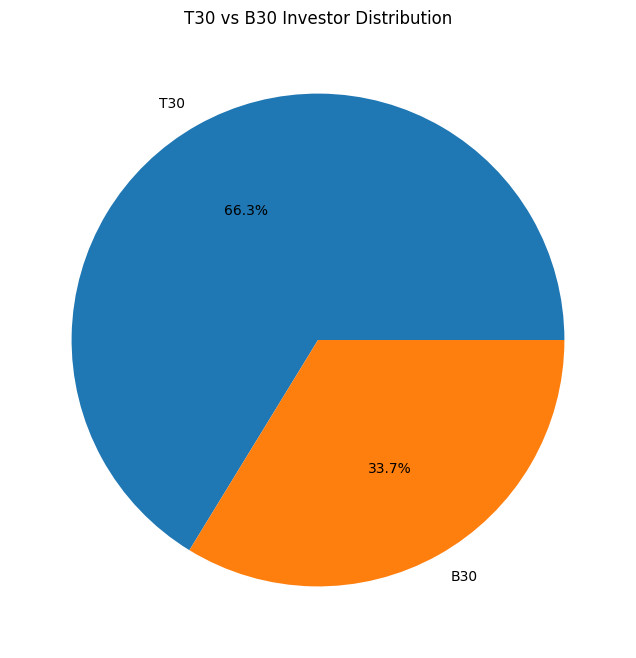

In [47]:
plt.figure(figsize=(8,8))

transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('T30 vs B30 Investor Distribution')

plt.ylabel('')

plt.show()

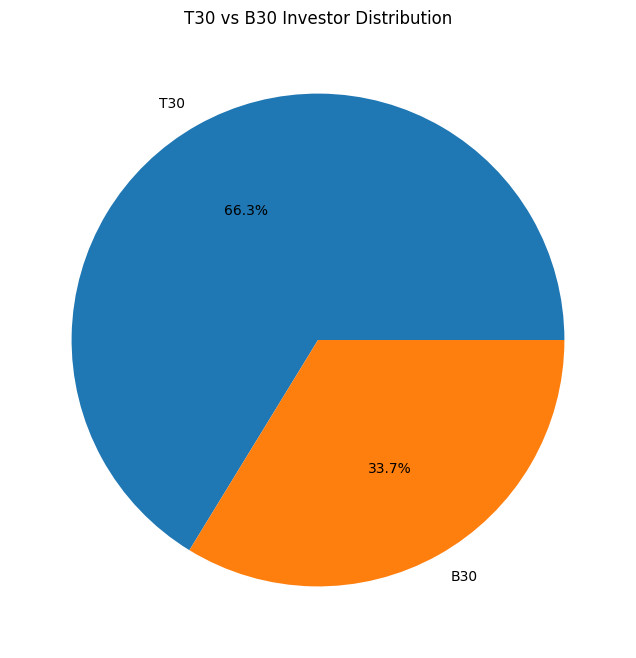

In [48]:
plt.figure(figsize=(8,8))

transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('T30 vs B30 Investor Distribution')

plt.ylabel('')

plt.savefig(
    "../charts/t30_b30_distribution.png",
    bbox_inches='tight'
)

plt.show()

In [49]:
import os

print(os.listdir("../charts"))

['age_distribution.png', 'age_group_boxplot.png', 'aum_growth.png', 'category_heatmap.png', 'gender_distribution.png', 'sip_trend.html', 'state_investment.png', 't30_b30_distribution.png']


In [50]:
folio['month'] = pd.to_datetime(folio['month'])

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [51]:
fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    title='Mutual Fund Industry Folio Growth (2022-2025)',
    markers=True
)

fig.show()

In [52]:
folio[['month','total_folios_crore']].tail()

,month,total_folios_crore
16,2025-07-01,24.57
17,2025-08-01,24.89
18,2025-09-01,25.19
19,2025-10-01,25.60
20,2025-12-01,26.12


In [53]:
fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    title='Mutual Fund Industry Folio Growth (2022-2025)',
    markers=True
)

fig.add_annotation(
    x='2022-01-01',
    y=13.26,
    text='13.26 Cr',
    showarrow=True
)

fig.add_annotation(
    x='2025-12-01',
    y=26.12,
    text='26.12 Cr',
    showarrow=True
)

fig.show()

In [54]:
fig.write_html("../charts/folio_growth.html")

In [55]:
import os

print(os.listdir("../charts"))

['age_distribution.png', 'age_group_boxplot.png', 'aum_growth.png', 'category_heatmap.png', 'folio_growth.html', 'gender_distribution.png', 'sip_trend.html', 'state_investment.png', 't30_b30_distribution.png']


In [56]:
folio['month'] = pd.to_datetime(folio['month'])

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [57]:
import plotly.express as px

fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    title='Mutual Fund Industry Folio Growth',
    markers=True
)

fig.show()

In [58]:
print(folio[['month','total_folios_crore']])

        month  total_folios_crore
0  2022-01-01               13.26
1  2022-04-01               13.91
2  2022-07-01               13.85
3  2022-10-01               14.12
4  2023-01-01               14.81
5  2023-04-01               15.54
6  2023-07-01               16.28
7  2023-10-01               16.72
8  2024-01-01               17.78
9  2024-04-01               18.85
10 2024-07-01               19.98
11 2024-10-01               21.62
12 2024-12-01               22.89
13 2025-01-01               23.10
14 2025-03-01               23.45
15 2025-04-01               23.89
16 2025-07-01               24.57
17 2025-08-01               24.89
18 2025-09-01               25.19
19 2025-10-01               25.60
20 2025-12-01               26.12


In [59]:
fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    title='Mutual Fund Industry Folio Growth',
    markers=True
)

fig.add_annotation(
    x=folio.iloc[0]['month'],
    y=folio.iloc[0]['total_folios_crore'],
    text='13.26 Cr',
    showarrow=True
)

fig.add_annotation(
    x=folio.iloc[-1]['month'],
    y=folio.iloc[-1]['total_folios_crore'],
    text='26.12 Cr',
    showarrow=True
)

fig.show()

In [61]:
fig.write_html("../charts/folio_growth.html")

In [62]:
import os

print(os.listdir("../charts"))

['age_distribution.png', 'age_group_boxplot.png', 'aum_growth.png', 'category_heatmap.png', 'folio_growth.html', 'gender_distribution.png', 'sip_trend.html', 'state_investment.png', 't30_b30_distribution.png']


In [63]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [64]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

nav_history['nav'] = pd.to_numeric(
    nav_history['nav']
)

In [65]:
pivot_nav = nav_history.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

pivot_nav.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,...,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,...,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,...,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,...,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,...,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


In [66]:
selected_funds = pivot_nav.columns[:10]

pivot_nav = pivot_nav[selected_funds]

In [67]:
returns = pivot_nav.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [68]:
corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


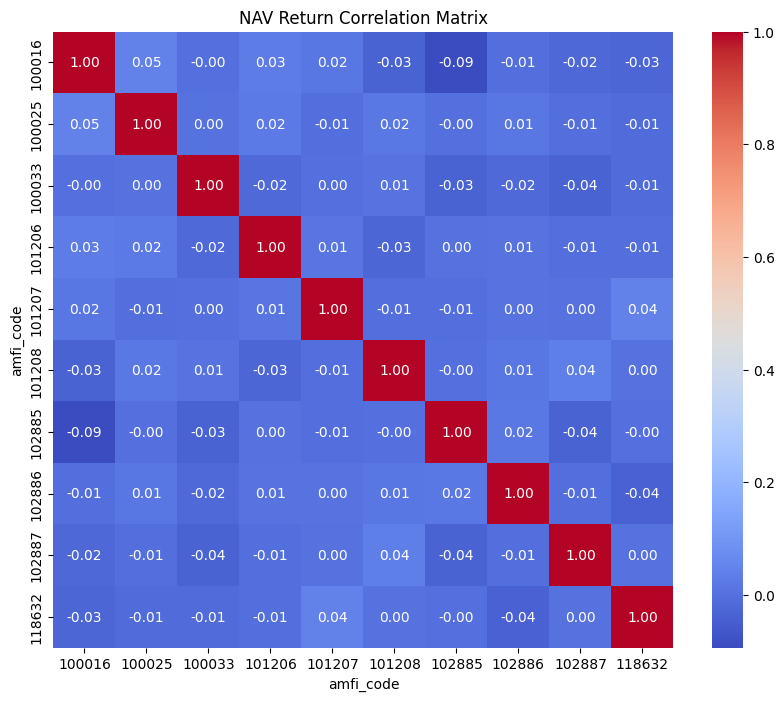

In [69]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('NAV Return Correlation Matrix')

plt.show()

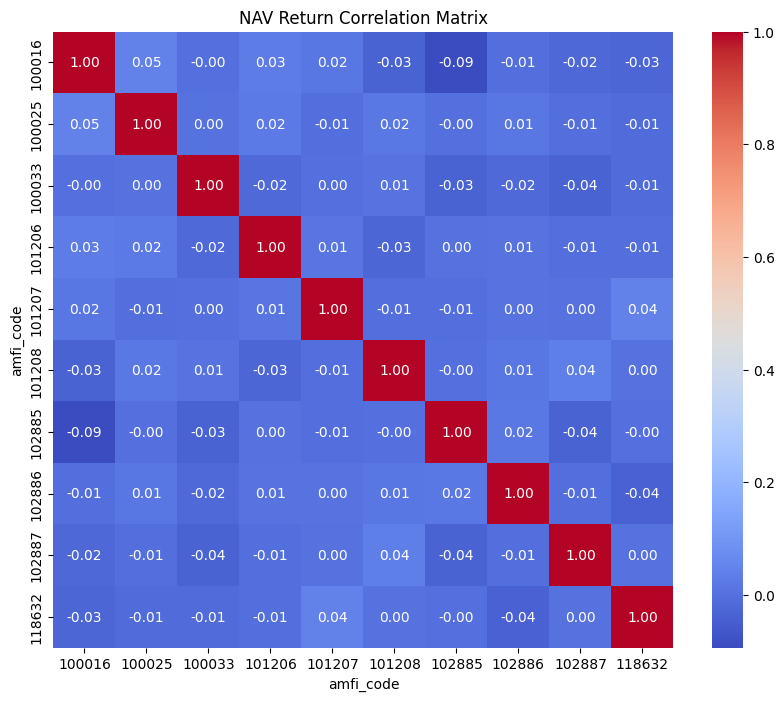

In [70]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('NAV Return Correlation Matrix')

plt.savefig(
    "../charts/correlation_matrix.png",
    bbox_inches='tight'
)

plt.show()

In [71]:
import os

print(os.listdir("../charts"))

['age_distribution.png', 'age_group_boxplot.png', 'aum_growth.png', 'category_heatmap.png', 'correlation_matrix.png', 'folio_growth.html', 'gender_distribution.png', 'sip_trend.html', 'state_investment.png', 't30_b30_distribution.png']


In [73]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [74]:
holdings['weight_pct'] = pd.to_numeric(
    holdings['weight_pct']
)

holdings.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB


In [75]:
sector_data = (
    holdings.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

sector_data

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

In [76]:
import plotly.express as px

fig = px.pie(
    values=sector_data.values,
    names=sector_data.index,
    hole=0.5,
    title='Sector Allocation Across Mutual Funds'
)

fig.show()

In [77]:
fig = px.pie(
    values=sector_data.values,
    names=sector_data.index,
    hole=0.5,
    title='Sector Allocation Across Mutual Funds'
)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

fig.show()

In [78]:
fig.write_html("../charts/sector_allocation.html")

In [79]:
import os

print(os.listdir("../charts"))

['age_distribution.png', 'age_group_boxplot.png', 'aum_growth.png', 'category_heatmap.png', 'correlation_matrix.png', 'folio_growth.html', 'gender_distribution.png', 'sector_allocation.html', 'sip_trend.html', 'state_investment.png', 't30_b30_distribution.png']


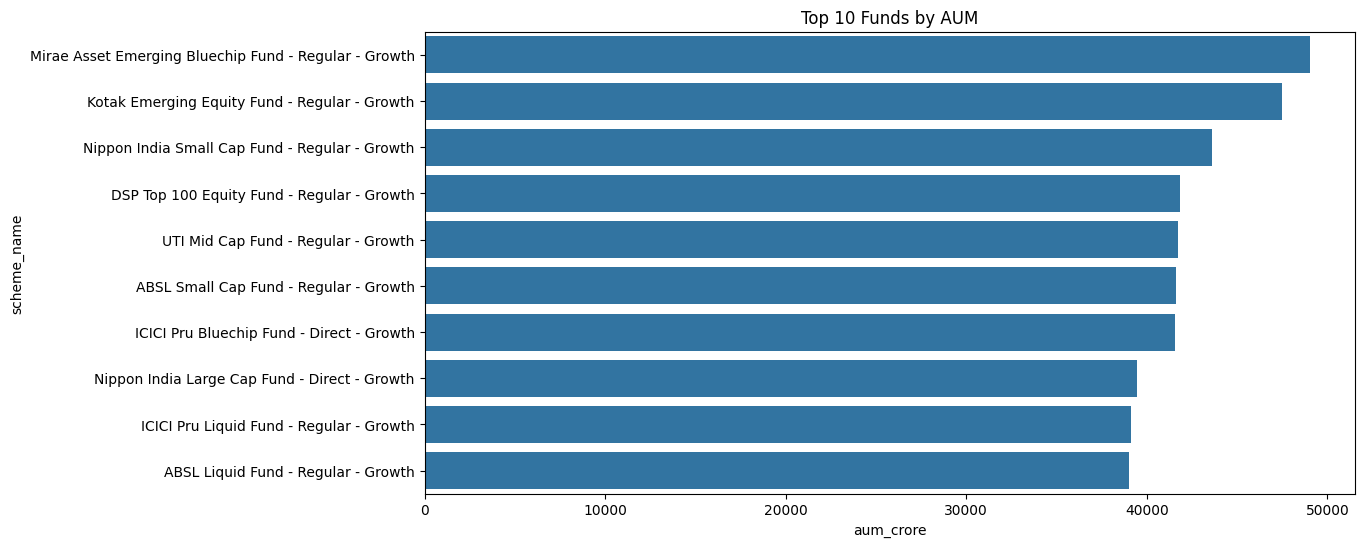

In [80]:
top_funds = performance.nlargest(
    10,
    'aum_crore'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x='aum_crore',
    y='scheme_name'
)

plt.title('Top 10 Funds by AUM')

plt.savefig(
    "../charts/top10_funds_aum.png",
    bbox_inches='tight'
)

plt.show()

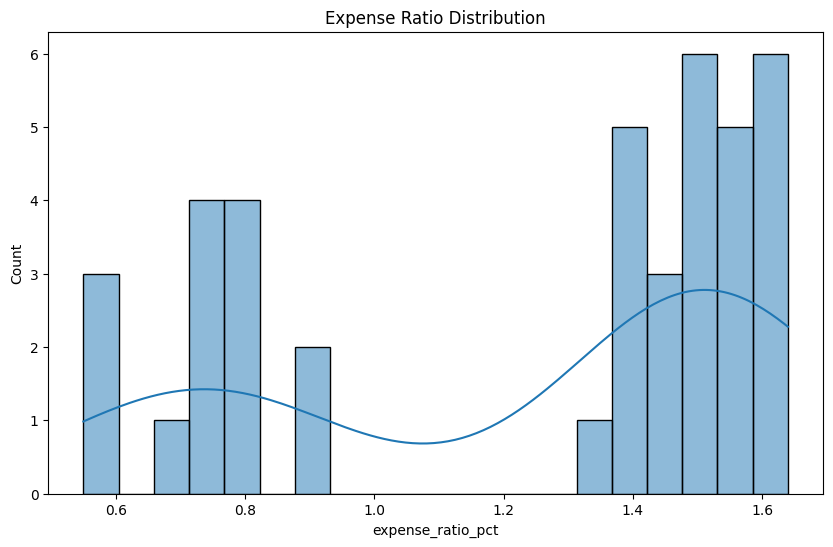

In [81]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance['expense_ratio_pct'],
    bins=20,
    kde=True
)

plt.title('Expense Ratio Distribution')

plt.savefig(
    "../charts/expense_ratio_distribution.png",
    bbox_inches='tight'
)

plt.show()

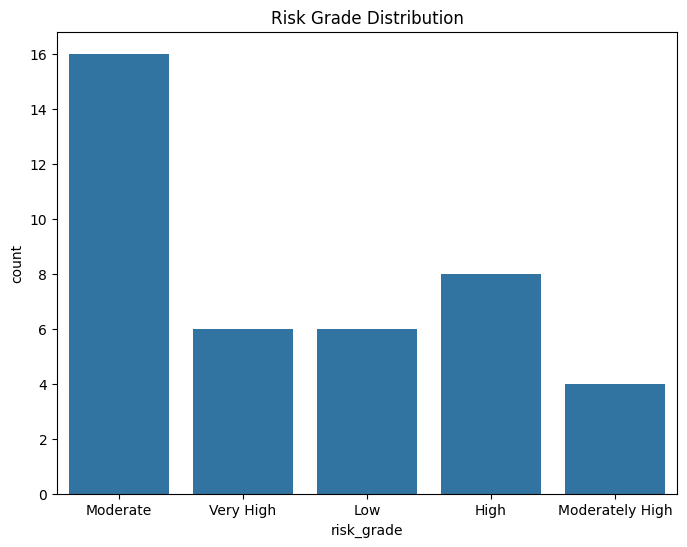

In [82]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=performance,
    x='risk_grade'
)

plt.title('Risk Grade Distribution')

plt.savefig(
    "../charts/risk_grade_distribution.png",
    bbox_inches='tight'
)

plt.show()

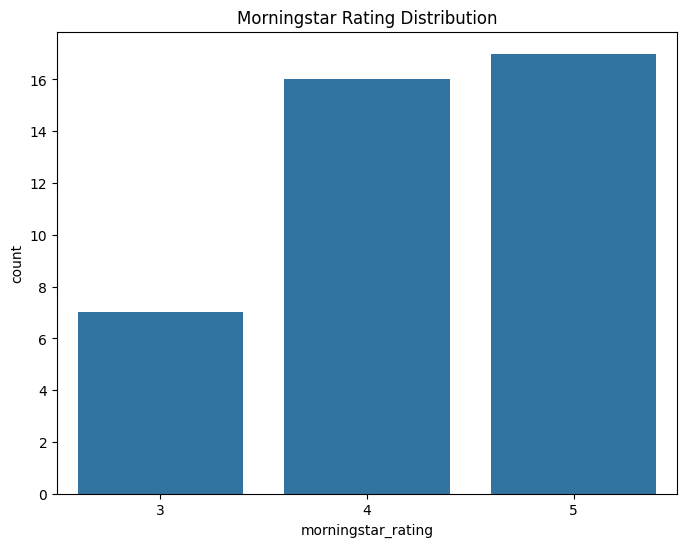

In [83]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=performance,
    x='morningstar_rating'
)

plt.title('Morningstar Rating Distribution')

plt.savefig(
    "../charts/morningstar_rating.png",
    bbox_inches='tight'
)

plt.show()

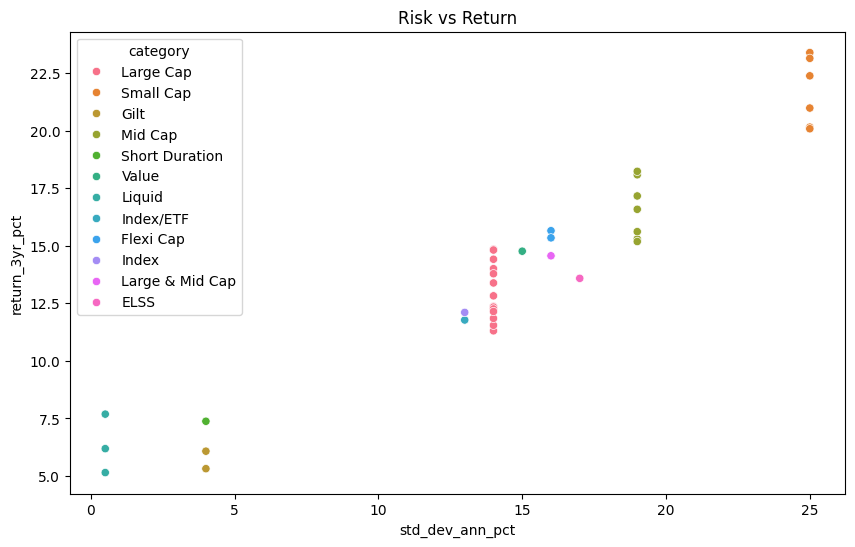

In [84]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x='std_dev_ann_pct',
    y='return_3yr_pct',
    hue='category'
)

plt.title('Risk vs Return')

plt.savefig(
    "../charts/risk_vs_return.png",
    bbox_inches='tight'
)

plt.show()

# EDA Findings and Insights

## Insight 1
Mutual fund NAVs exhibited a strong upward trend between 2022 and 2025, reflecting overall growth in the Indian mutual fund industry.

## Insight 2
SBI Mutual Fund maintained the highest Assets Under Management (AUM) among all fund houses, demonstrating strong investor confidence and market leadership.

## Insight 3
Monthly SIP inflows increased steadily over the study period and reached a record high of ₹31,002 crore in December 2025.

## Insight 4
Flexi Cap, Large Cap, and Mid Cap categories consistently attracted the highest net inflows.

## Insight 5
The majority of mutual fund investors belong to the 26–45 age group.

## Insight 6
Male investors slightly outnumber female investors.

## Insight 7
T30 cities contribute a larger share of investments than B30 cities.

## Insight 8
Total mutual fund folios increased from 13.26 crore to 26.12 crore between 2022 and 2025.

## Insight 9
Large-cap funds show strong positive return correlations.

## Insight 10
Financial Services and Information Technology sectors have the highest portfolio allocation.